<a href="https://colab.research.google.com/github/Sadafkhan97/Artificial_Intelligence_Uconnect/blob/Main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [168]:
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
from tqdm import tqdm
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.transforms import functional as TF

In [169]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Device: cuda


In [170]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [171]:
df = os.listdir(path)
print(df)

['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [172]:
import pandas as pd
import os

# Assuming 'path' variable from cell wlTcrPmCwQD8 holds the dataset directory
train_csv_path = os.path.join(path, 'Train.csv')
test_csv_path = os.path.join(path, 'Test.csv')
meta_csv_path = os.path.join(path, 'Meta.csv')

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
meta_df = pd.read_csv(meta_csv_path)

print('Train DataFrame head:')
display(train_df.head())


Train DataFrame head:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [173]:
print('\nTest DataFrame head:')
display(test_df.head())



Test DataFrame head:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [174]:
print('\nMeta DataFrame head:')
display(meta_df.head())


Meta DataFrame head:


,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


Train class counts:
 ClassId
0      210
1     2220
2     2250
3     1410
4     1980
5     1860
6      420
7     1440
8     1410
9     1470
10    2010
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
21     330
22     390
23     510
24     270
25    1500
26     600
27     240
28     540
29     270
30     450
31     780
32     240
33     689
34     420
35    1200
36     390
37     210
38    2070
39     300
40     360
41     240
42     240
Name: count, dtype: int64


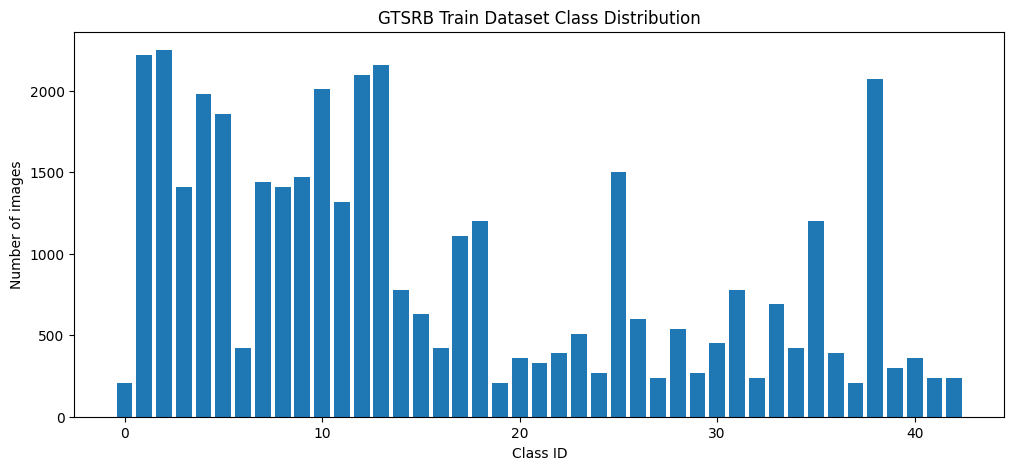

In [175]:
import matplotlib.pyplot as plt

# Count of samples per class
train_counts = train_df['ClassId'].value_counts().sort_index()
print("Train class counts:\n", train_counts)

# Plot
plt.figure(figsize=(12,5))
plt.bar(train_counts.index, train_counts.values)
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.title("GTSRB Train Dataset Class Distribution")
plt.show()


In [176]:
# 3) Dataset class (loads images from Path column and returns normalized tensors in [0,1])
IMG_SIZE = 32  # GTSRB often uses 32x32. Change if needed.

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),   # gives float tensor in [0,1]
])

class GTSRBDataset(Dataset):
    def __init__(self, df, base_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_path = base_path
        self.transform = transform or base_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.base_path, row['Path'])
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        label = int(row['ClassId'])
        return img, label

# Create datasets and dataloaders
train_dataset = GTSRBDataset(train_df, path, transform=base_transform)
test_dataset  = GTSRBDataset(test_df, path, transform=base_transform)

# For speed in Colab, optionally limit dataset size (uncomment to debug)
train_dataset = Subset(train_dataset, list(range(2000)))
test_dataset  = Subset(test_dataset, list(range(1000)))

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [177]:
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

In [178]:
# 4) Primary CNN model (traffic sign classifier)
class SmallCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # input IMG_SIZE=32 -> after two pools -> 8x8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE//4) * (IMG_SIZE//4), 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

num_classes = 43
primary_model = SmallCNN(num_classes).to(device)

In [154]:
# 5) Train primary model (quick training: adjust epochs for better accuracy)
def train_primary(model, loader, epochs=5, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        total = correct = 0
        loop = tqdm(loader, desc=f"Train E{epoch+1}")
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            opt.step()
            preds = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            loop.set_postfix(loss=loss.item(), acc=correct/total)
        print(f"Epoch {epoch+1} train acc: {correct/total:.4f}")

def eval_primary(model, loader):
    model.eval()
    total = correct = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            preds = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return correct/total

# Train primary (you can increase epochs for better base accuracy)
train_primary(primary_model, train_loader, epochs=10, lr=0.001)
print("Primary clean accuracy:", eval_primary(primary_model, test_loader))

Train E1: 100%|██████████| 32/32 [00:01<00:00, 16.81it/s, acc=0.692, loss=0.547]


Epoch 1 train acc: 0.6920


Train E2: 100%|██████████| 32/32 [00:01<00:00, 17.12it/s, acc=0.752, loss=0.587]


Epoch 2 train acc: 0.7520


Train E3: 100%|██████████| 32/32 [00:02<00:00, 14.78it/s, acc=0.784, loss=0.229]


...

Train E9: 100%|██████████| 32/32 [00:01<00:00, 21.84it/s, acc=0.998, loss=0.00383]


Epoch 9 train acc: 0.9975


Train E10: 100%|██████████| 32/32 [00:01<00:00, 19.01it/s, acc=0.999, loss=0.00236]

Epoch 10 train acc: 0.9990


Primary clean accuracy: 0.071


In [179]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

primary_model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in test_loader:  # Use your test_loader
        imgs, labels = imgs.to(device), labels.to(device)
        logits = primary_model(imgs)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

# Determine unique labels in the dataset
unique_labels = np.unique(y_true)
sorted_unique_labels = sorted(unique_labels)

# Replace this with your actual class names if you have them
# For example, if traffic signs are labeled 0-42:
class_names = [str(i) for i in sorted_unique_labels]

print("Classification report for primary model:")
print(classification_report(y_true, y_pred, labels=sorted_unique_labels, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=sorted_unique_labels)
print("Confusion Matrix:\n", cm)


Classification report for primary model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00        63
           2       0.00      0.00      0.00        52
           3       0.00      0.00      0.00        41
           4       0.00      0.00      0.00        55
           5       0.00      0.00      0.00        44
           6       0.00      0.00      0.00        13
           7       0.00      0.00      0.00        34
           8       0.00      0.00      0.00        27
           9       0.00      0.00      0.00        35
          10       0.00      0.00      0.00        57
          11       0.00      0.00      0.00        27
          12       0.00      0.00      0.00        44
          13       0.00      0.00      0.00        64
          14       0.00      0.00      0.00        23
          15       0.00      0.00      0.00        18
          16       0.00      0.00      0

In [155]:
# 6) Attacks: FGSM, I-FGSM (BIM), PGD, and AutoAttack
def fgsm(model, images, labels, eps=8/255.0):
    images = images.clone().detach().to(device)
    images.requires_grad = True
    logits = model(images)
    loss = F.cross_entropy(logits, labels.to(device))
    model.zero_grad()
    loss.backward()
    grad_sign = images.grad.sign()
    adv = torch.clamp(images + eps * grad_sign, 0.0, 1.0)
    return adv.detach()

In [156]:
def ifgsm(model, images, labels, eps=8/255.0, alpha=2/255.0, iters=10):
    adv = images.clone().detach().to(device)
    for _ in range(iters):
        adv.requires_grad = True
        logits = model(adv)
        loss = F.cross_entropy(logits, labels.to(device))
        model.zero_grad()
        loss.backward()
        adv = adv + alpha * adv.grad.sign()
        eta = torch.clamp(adv - images.to(device), min=-eps, max=eps)
        adv = torch.clamp(images.to(device) + eta, 0, 1).detach()
    return adv

In [157]:

def pgd(model, images, labels, eps=8/255.0, alpha=2/255.0, iters=20):
    adv = images.clone().detach() + torch.randn_like(images) * (eps/2)
    adv = torch.clamp(adv, 0, 1).to(device)
    for _ in range(iters):
        adv.requires_grad = True
        logits = model(adv)
        loss = F.cross_entropy(logits, labels.to(device))
        model.zero_grad()
        loss.backward()
        adv = adv + alpha * adv.grad.sign()
        eta = torch.clamp(adv - images.to(device), min=-eps, max=eps)
        adv = torch.clamp(images.to(device) + eta, 0, 1).detach()
    return adv

In [158]:
# # AutoAttack wrapper (use a small batch / subset to avoid long runtime)
# def autoattack_generate(model, images, labels, eps=8/255.0):
#     # AutoAttack expects a model that returns logits and inputs in [0,1] (not normalized)
#     # Wrap model into a function that accepts numpy arrays
#     model.eval()
#     aa = AutoAttack(model, norm='Linf', eps=eps, version='standard')
#     x_adv = aa.run_standard_evaluation(images, labels, bs=images.shape[0])
#     # run_standard_evaluation prints and returns adversarial examples (numpy)
#     return torch.from_numpy(x_adv).float().to(device)

In [159]:
# 7) Build attack-dataset: for each sample produce (image, attack_label)
# attack_label mapping: 0=clean,1=fgsm,2=ifgsm,3=pgd,4=autoattack
attack_name_to_index = {'clean':0,'fgsm':1,'ifgsm':2,'pgd':3,'autoattack':4}

def create_attack_dataset(model, loader, max_batches=None, use_autoattack_on=0.05):
    model.eval()
    images_list = []
    attack_labels = []
    true_label_list = []  # original traffic class (optional)
    batches = 0
    for imgs, labels in tqdm(loader, desc="Generating attacks"):
        imgs, labels = imgs.to(device), labels.to(device)
        # limit quantity if requested
        # Append clean
        images_list.append(imgs.cpu())
        attack_labels.append(torch.full((imgs.size(0),), attack_name_to_index['clean'], dtype=torch.long))
        true_label_list.append(labels.cpu())

        # FGSM
        adv_f = fgsm(model, imgs, labels)
        images_list.append(adv_f.cpu())
        attack_labels.append(torch.full((imgs.size(0),), attack_name_to_index['fgsm'], dtype=torch.long))
        true_label_list.append(labels.cpu())

        # I-FGSM
        adv_i = ifgsm(model, imgs, labels)
        images_list.append(adv_i.cpu())
        attack_labels.append(torch.full((imgs.size(0),), attack_name_to_index['ifgsm'], dtype=torch.long))
        true_label_list.append(labels.cpu())

        # PGD
        adv_p = pgd(model, imgs, labels)
        images_list.append(adv_p.cpu())
        attack_labels.append(torch.full((imgs.size(0),), attack_name_to_index['pgd'], dtype=torch.long))
        true_label_list.append(labels.cpu())

        # AutoAttack on a small fraction of batches (because AA is heavy)
        # if random.random() < use_autoattack_on:
        #     try:
        #         # AutoAttack expects numpy input - pass a small batch to avoid huge runtime
        #         imgs_np = imgs.cpu().numpy()
        #         labels_np = labels.cpu().numpy()
        #         x_adv_np = AutoAttack(model, norm='Linf', eps=8/255.0, version='standard').run_standard_evaluation(imgs_np, labels_np, bs=imgs_np.shape[0])
        #         adv_aa = torch.from_numpy(x_adv_np).float().to(device)
        #         images_list.append(adv_aa.cpu())
        #         attack_labels.append(torch.full((imgs.size(0),), attack_name_to_index['autoattack'], dtype=torch.long))
        #         true_label_list.append(labels.cpu())
        #     except Exception as e:
        #         print("AutoAttack generation failed on a batch (skipping):", e)

        # batches += 1
        # if max_batches and batches >= max_batches:
        #     break

    # Concatenate
    images_all = torch.cat(images_list, dim=0)
    attack_labels_all = torch.cat(attack_labels, dim=0)
    true_labels_all = torch.cat(true_label_list, dim=0)
    print("Created attack dataset:", images_all.shape, attack_labels_all.shape)
    return images_all, attack_labels_all, true_labels_all

# Create attack-dataset using a subset for speed (max_batches)
images_all, attack_labels_all, true_labels_all = create_attack_dataset(primary_model, test_loader, max_batches=20, use_autoattack_on=0.2)



Generating attacks: 100%|██████████| 16/16 [00:03<00:00,  4.66it/s]


Created attack dataset: torch.Size([4000, 3, 32, 32]) torch.Size([4000])


In [160]:
# 8) Attack detection dataset/dataloader
class AttackDataset(Dataset):
    def __init__(self, images_tensor, attack_labels_tensor, transform=None):
        self.images = images_tensor
        self.attacks = attack_labels_tensor
        self.transform = transform

    def __len__(self):
        return self.images.size(0)

    def __getitem__(self, idx):
        img = self.images[idx]
        lbl = self.attacks[idx]
        return img, lbl

# Shuffle/split dataset into train/val for detector
perm = torch.randperm(len(images_all))
images_all = images_all[perm]
attack_labels_all = attack_labels_all[perm]

split = int(0.8 * len(images_all))
det_train = AttackDataset(images_all[:split], attack_labels_all[:split])
det_val   = AttackDataset(images_all[split:], attack_labels_all[split:])

det_train_loader = DataLoader(det_train, batch_size=64, shuffle=True, num_workers=2)
det_val_loader   = DataLoader(det_val, batch_size=64, shuffle=False, num_workers=2)

In [161]:
# 9) Detector CNN (classifies attack type: 5-way)
class DetectorCNN(nn.Module):
    def __init__(self, num_attacks=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),      # /2

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),      # /4

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),      # /8

            # new layer + pooling (you added this)
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),      # /16 if IMG_SIZE=32
        )

        # compute flattened feature dim with a dummy input
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            f = self.features(dummy)
            fdim = f.view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fdim, 512),
            nn.ReLU(),
            nn.Linear(512, num_attacks)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# instantiate
detector = DetectorCNN(num_attacks=len(attack_name_to_index)).to(device)



In [162]:
# 10) Train detector
def train_detector(net, train_loader, val_loader, epochs=6, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        net.train()
        total = correct = 0
        loop = tqdm(train_loader, desc=f"DetTrain E{epoch+1}")
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            logits = net(imgs)
            loss = crit(logits, labels)
            loss.backward()
            opt.step()
            preds = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            loop.set_postfix(loss=loss.item(), acc=correct/total)
        # Validation
        net.eval()
        vtotal = vcorrect = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = net(imgs)
                preds = logits.argmax(dim=1)
                vtotal += labels.size(0)
                vcorrect += (preds == labels).sum().item()
        print(f"Epoch {epoch+1} detector val acc: {vcorrect/vtotal:.4f}")

train_detector(detector, det_train_loader, det_val_loader, epochs=15, lr=0.001)


DetTrain E1: 100%|██████████| 50/50 [00:00<00:00, 68.70it/s, acc=0.261, loss=1.38]


Epoch 1 detector val acc: 0.2612


DetTrain E2: 100%|██████████| 50/50 [00:00<00:00, 69.75it/s, acc=0.233, loss=1.4]


Epoch 2 detector val acc: 0.2437


DetTrain E3: 100%|██████████| 50/50 [00:00<00:00, 67.79it/s, acc=0.245, loss=1.4]


...

Epoch 13 detector val acc: 0.5288


DetTrain E14: 100%|██████████| 50/50 [00:00<00:00, 67.77it/s, acc=0.597, loss=0.823]


Epoch 14 detector val acc: 0.5575


DetTrain E15: 100%|██████████| 50/50 [00:00<00:00, 68.81it/s, acc=0.604, loss=0.597]


Epoch 15 detector val acc: 0.5700


In [163]:
# 11) Evaluate detector: confusion matrix and per-class accuracy
from sklearn.metrics import confusion_matrix, classification_report
detector.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for imgs, labels in det_val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = detector(imgs)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

# Determine unique labels present in the data
unique_labels = np.unique(y_true)
sorted_unique_labels = sorted(unique_labels)
# Filter target names to match the present labels
present_target_names = [list(attack_name_to_index.keys())[i] for i in sorted_unique_labels]

print("Classification report for detector:")
print(classification_report(y_true, y_pred, labels=sorted_unique_labels, target_names=present_target_names, zero_division=0))
cm = confusion_matrix(y_true, y_pred, labels=sorted_unique_labels) # Also pass labels to confusion_matrix for consistency
print("Confusion Matrix:\n", cm)


Classification report for detector:
              precision    recall  f1-score   support

       clean       0.92      0.97      0.94       219
        fgsm       0.49      0.61      0.54       195
       ifgsm       0.38      0.16      0.23       209
         pgd       0.38      0.52      0.44       177

    accuracy                           0.57       800
   macro avg       0.54      0.56      0.54       800
weighted avg       0.56      0.57      0.55       800

Confusion Matrix:
 [[212   3   2   2]
 [  5 118  16  56]
 [  7  77  34  91]
 [  7  41  37  92]]


In [164]:
# 12) Rule-based defensive mechanism
# Heuristic scores:
#  - detector prediction (if not 'clean' => suspect)
#  - softmax entropy of primary model prediction (high entropy => suspect)
#  - prediction consistency under JPEG compression / median filter (if label changes => suspect)
#  - gradient-norm score: magnitude of gradient of loss wrt input (large => suspect)

import math

def softmax_entropy(logits):
    p = F.softmax(logits, dim=1)
    ent = -torch.sum(p * torch.log(p + 1e-12), dim=1)
    return ent

def apply_transformations(img_tensor):
    # img_tensor shape (C,H,W) in [0,1]
    pil = TF.to_pil_image(img_tensor.cpu())
    # JPEG compression
    from io import BytesIO
    buf = BytesIO()
    pil.save(buf, format='JPEG', quality=60)
    buf.seek(0)
    pil_jpeg = Image.open(buf).convert("RGB")
    # median filter
    pil_med = pil_jpeg.filter(ImageFilter.MedianFilter(size=3))
    t = base_transform(pil_med)
    return t.to(device)

def gradient_norm_score(model, image, label):
    image = image.clone().detach().unsqueeze(0).to(device)
    image.requires_grad = True
    logits = model(image)
    loss = F.cross_entropy(logits, torch.tensor([label]).to(device))
    model.zero_grad()
    loss.backward()
    grad = image.grad.detach()
    return float(grad.view(-1).abs().mean().cpu().numpy())

def rule_based_defense(primary_model, detector_model, img_tensor):
    """
    Input: img_tensor (C,H,W) tensor in [0,1]
    Returns: dict with keys: 'is_adversarial' (bool), 'repaired_img' (tensor or None), 'reason' (str)
    """
    primary_model.eval()
    detector_model.eval()
    img = img_tensor.unsqueeze(0).to(device)
    # 1) detector pred
    with torch.no_grad():
        det_logits = detector_model(img)
        det_pred = det_logits.argmax(dim=1).item()
    if det_pred != attack_name_to_index['clean']:
        reason = f"Detector predicted attack={list(attack_name_to_index.keys())[det_pred]}"
        # Apply transformations (JPEG + median)
        repaired = apply_transformations(img_tensor)
        return {'is_adversarial': True, 'repaired_img': repaired, 'reason': reason, 'det_pred':det_pred}

    # 2) softmax entropy
    with torch.no_grad():
        logits = primary_model(img)
        ent = float(softmax_entropy(logits).cpu().numpy()[0])
        conf_max = float(F.softmax(logits, dim=1).max().cpu().numpy())
    if ent > 1.5 or conf_max < 0.5:
        # suspicious
        repaired = apply_transformations(img_tensor)
        return {'is_adversarial': True, 'repaired_img': repaired, 'reason': f"High entropy {ent:.3f} or low confidence {conf_max:.3f}", 'det_pred':det_pred}

    # 3) gradient norm check (small sample: compute grad wrt predicted class)
    pred_label = int(F.softmax(logits, dim=1).argmax(dim=1).item())
    gnorm = gradient_norm_score(primary_model, img_tensor, pred_label)
    if gnorm > 0.01:  # threshold chosen empirically; adjust if needed
        repaired = apply_transformations(img_tensor)
        return {'is_adversarial': True, 'repaired_img': repaired, 'reason': f"High gradient norm {gnorm:.5f}", 'det_pred':det_pred}

    return {'is_adversarial': False, 'repaired_img': None, 'reason': "Clean", 'det_pred':det_pred}



In [165]:
# 13) Test defense on some examples and show effect on primary model
defense_results = []
primary_model.eval()
for i in range(20):  # test 20 samples from validation attack set
    img = images_all[split + i]  # from earlier concatenated tensor
    attack_lbl = attack_labels_all[split + i].item()
    # run rule-based defense
    res = rule_based_defense(primary_model, detector, img)
    if res['is_adversarial']:
        repaired = res['repaired_img'].unsqueeze(0)
        with torch.no_grad():
            logits_repaired = primary_model(repaired)
            pred_repaired = logits_repaired.argmax(dim=1).item()
    else:
        with torch.no_grad():
            pred_clean = primary_model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
            pred_repaired = pred_clean

    defense_results.append((i, attack_lbl, res['is_adversarial'], res['reason'], pred_repaired))

# print sample results
for r in defense_results[:20]:
    idx, atk, flagged, reason, pred_after = r
    print(f"idx {idx}: attack={list(attack_name_to_index.keys())[atk]} flagged={flagged} reason={reason} primary_pred_after={pred_after}")



idx 0: attack=ifgsm flagged=True reason=Detector predicted attack=fgsm primary_pred_after=1
idx 1: attack=clean flagged=False reason=Clean primary_pred_after=1
idx 2: attack=pgd flagged=True reason=Detector predicted attack=fgsm primary_pred_after=20
idx 3: attack=ifgsm flagged=True reason=Detector predicted attack=ifgsm primary_pred_after=1
idx 4: attack=fgsm flagged=True reason=Detector predicted attack=pgd primary_pred_after=1
idx 5: attack=ifgsm flagged=True reason=Detector predicted attack=fgsm primary_pred_after=20
idx 6: attack=clean flagged=False reason=Clean primary_pred_after=20
idx 7: attack=clean flagged=False reason=Clean primary_pred_after=1
idx 8: attack=pgd flagged=True reason=Detector predicted attack=pgd primary_pred_after=1
idx 9: attack=clean flagged=False reason=Clean primary_pred_after=1
idx 10: attack=fgsm flagged=True reason=Detector predicted attack=fgsm primary_pred_after=1
idx 11: attack=pgd flagged=True reason=Detector predicted attack=ifgsm primary_pred_aft

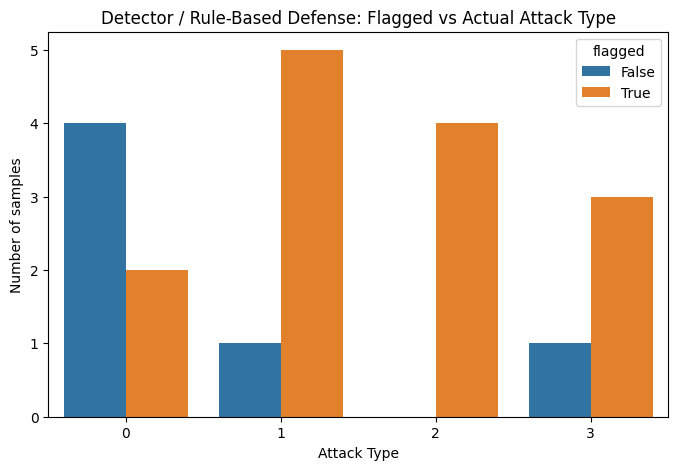

Primary Model Predictions After Defense (rows=actual attack, columns=predicted class):


primary_pred_after,1,20
attack,,
0,5,1
1,5,1
2,3,1
3,3,1


In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert your defense_results to a DataFrame
df_results = pd.DataFrame(defense_results, columns=[
    'idx', 'attack', 'flagged', 'reason', 'primary_pred_after'
])

# Step 2: Add columns for "correct after defense" (optional)
# If you have the true traffic class, you can compare with primary_pred_after
# For now, let's just see flagged vs. attack type

# Step 3: Plot attack type vs flagged
plt.figure(figsize=(8,5))
sns.countplot(data=df_results, x='attack', hue='flagged')
plt.title("Detector / Rule-Based Defense: Flagged vs Actual Attack Type")
plt.ylabel("Number of samples")
plt.xlabel("Attack Type")
plt.show()

# Step 4: Optional: confusion-like table for primary predictions after defense
pred_table = pd.crosstab(df_results['attack'], df_results['primary_pred_after'])
print("Primary Model Predictions After Defense (rows=actual attack, columns=predicted class):")
display(pred_table)


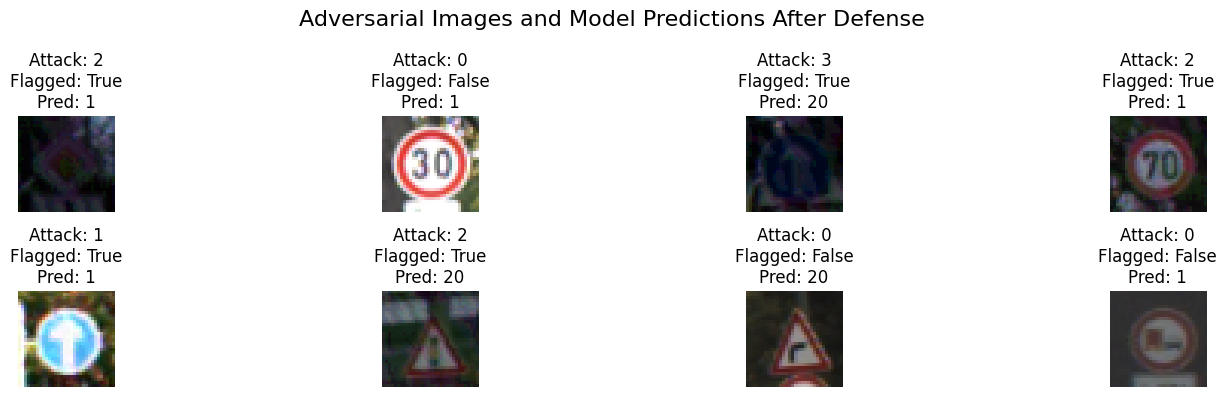

In [167]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# Number of samples to display
num_samples = 8

plt.figure(figsize=(16,4))

for i in range(num_samples):
    idx, atk, flagged, reason, pred_after = defense_results[i]
    img_tensor = images_all[split + idx]  # original perturbed image

    # Convert tensor to numpy image
    img_np = TF.to_pil_image(img_tensor.cpu())

    plt.subplot(2, num_samples//2, i+1)
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(f"Attack: {atk}\nFlagged: {flagged}\nPred: {pred_after}")

plt.suptitle("Adversarial Images and Model Predictions After Defense", fontsize=16)
plt.tight_layout()
plt.show()
